<a href="https://colab.research.google.com/github/Rio-HEPLab/ML4Physics/blob/PPGF-2025-1/Convolutional_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf
tf.config.run_functions_eagerly(True) # This ensures eager execution within tf.function
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

2025-06-22 18:37:59.377916: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750617479.401508    1035 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750617479.408536    1035 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
num_samples = 20000
X_train = X_train[ : num_samples ]
y_train = y_train[ : num_samples ]
print ( X_train.shape )

(20000, 28, 28)


In [ ]:
print('X_train.shape', X_train.shape)

# Reshape and normalize
X_train = X_train.reshape( X_train.shape[0], 28, 28, 1 ).astype('float32')
X_train = ( X_train / 255 - 0.5 ) * 2
print('X_train reshape:', X_train.shape)

# Batch and shuffle the data
batch_size = 256
train_dataset = tf.data.Dataset.from_tensor_slices( X_train ).shuffle(num_samples).batch( batch_size )

X_train.shape (20000, 28, 28)
X_train reshape: (20000, 28, 28, 1)


I0000 00:00:1750617483.478940    1035 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


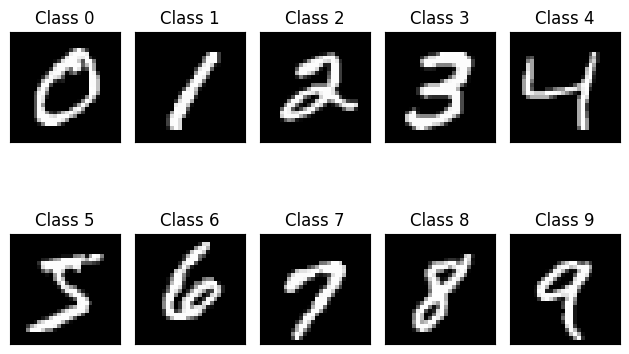

In [ ]:
fig = plt.figure()
for i in range(10):
    plt.subplot(2, 5, i+1)
    x_y = X_train[y_train == i]
    plt.imshow(x_y[0], cmap='gray', interpolation='none')
    plt.title("Class %d" % (i))
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

In [ ]:
latent_dim = 100
def generator_model():
    model = tf.keras.Sequential()
    model.add( tf.keras.Input( shape=(latent_dim,) ) )
    model.add(layers.Dense( 7*7*256, use_bias=False ) )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)  # Note: None is the batch size

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model
generator = generator_model()

In [ ]:
def discriminator_model():
    model = tf.keras.Sequential()
    model.add( tf.keras.Input( shape=[28, 28, 1] ) )
    model.add( layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same') )
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model
discriminator = discriminator_model()

I0000 00:00:1750617485.136066    1035 cuda_dnn.cc:529] Loaded cuDNN version 90300


Epoch: 0, disc. loss: 0.8199609518051147, gen. loss: 0.45344170928001404. Time for epoch 1 is 17.606465339660645 sec
Epoch: 1, disc. loss: 0.7221232652664185, gen. loss: 0.6585760116577148. Time for epoch 2 is 14.820044040679932 sec
Epoch: 2, disc. loss: 0.6272104978561401, gen. loss: 0.740752100944519. Time for epoch 3 is 14.721635341644287 sec
Epoch: 3, disc. loss: 0.6835334300994873, gen. loss: 0.7000209093093872. Time for epoch 4 is 15.248340606689453 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


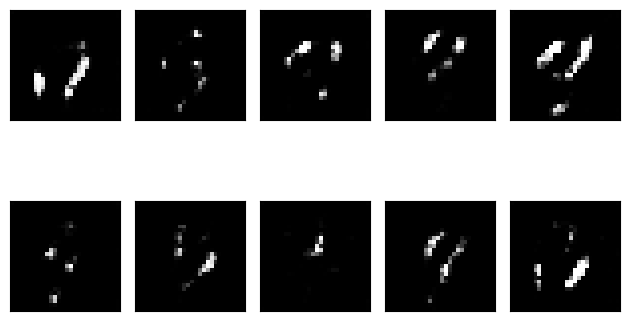

Epoch: 4, disc. loss: 0.6756327152252197, gen. loss: 0.713291347026825. Time for epoch 5 is 15.222409725189209 sec
Epoch: 5, disc. loss: 0.6297743320465088, gen. loss: 0.7489140629768372. Time for epoch 6 is 14.842318534851074 sec
Epoch: 6, disc. loss: 0.6691094636917114, gen. loss: 0.6571781039237976. Time for epoch 7 is 14.75468111038208 sec
Epoch: 7, disc. loss: 0.7207059264183044, gen. loss: 0.61070317029953. Time for epoch 8 is 14.868151903152466 sec
Epoch: 8, disc. loss: 0.5864102840423584, gen. loss: 0.8920567035675049. Time for epoch 9 is 14.87219762802124 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


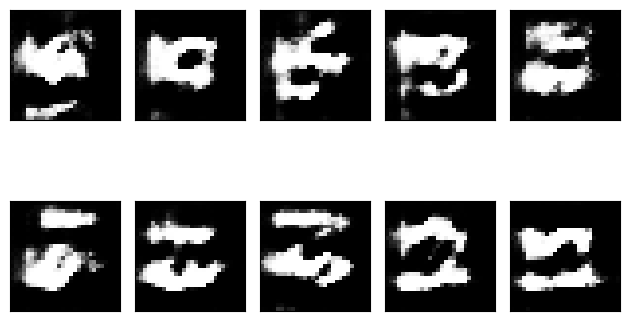

Epoch: 9, disc. loss: 0.6082063913345337, gen. loss: 0.6882892847061157. Time for epoch 10 is 15.248282670974731 sec
Epoch: 10, disc. loss: 0.5974644422531128, gen. loss: 0.8457303047180176. Time for epoch 11 is 14.813527584075928 sec
Epoch: 11, disc. loss: 0.6692105531692505, gen. loss: 0.692365825176239. Time for epoch 12 is 14.873433113098145 sec
Epoch: 12, disc. loss: 0.6793308258056641, gen. loss: 1.2870237827301025. Time for epoch 13 is 14.92939019203186 sec
Epoch: 13, disc. loss: 0.592880368232727, gen. loss: 0.6281477808952332. Time for epoch 14 is 14.930504083633423 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


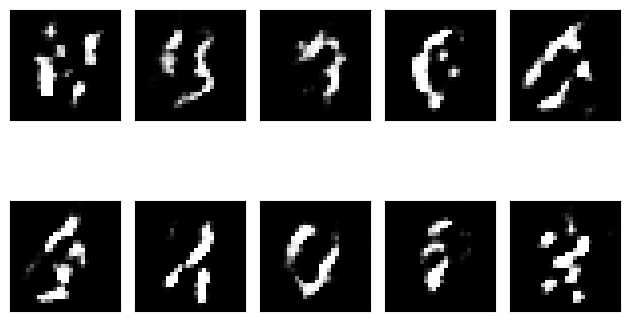

Epoch: 14, disc. loss: 0.710706353187561, gen. loss: 0.7541257739067078. Time for epoch 15 is 15.095459222793579 sec
Epoch: 15, disc. loss: 0.569277822971344, gen. loss: 0.8521162271499634. Time for epoch 16 is 14.787326097488403 sec
Epoch: 16, disc. loss: 0.5600782036781311, gen. loss: 0.836310625076294. Time for epoch 17 is 14.893458604812622 sec
Epoch: 17, disc. loss: 0.6607974171638489, gen. loss: 0.8187761306762695. Time for epoch 18 is 14.776280403137207 sec
Epoch: 18, disc. loss: 0.6229270696640015, gen. loss: 0.7669466733932495. Time for epoch 19 is 14.90485405921936 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


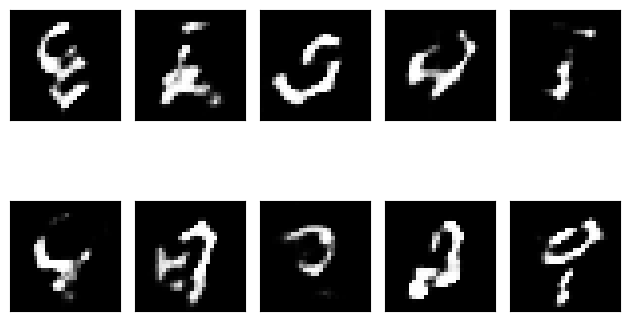

Epoch: 19, disc. loss: 0.6707109808921814, gen. loss: 0.6033453941345215. Time for epoch 20 is 15.136032819747925 sec
Epoch: 20, disc. loss: 0.7177513837814331, gen. loss: 0.626020610332489. Time for epoch 21 is 14.920933246612549 sec
Epoch: 21, disc. loss: 0.7281759977340698, gen. loss: 0.8215708136558533. Time for epoch 22 is 14.719334125518799 sec
Epoch: 22, disc. loss: 0.6453167200088501, gen. loss: 0.681932806968689. Time for epoch 23 is 14.83128809928894 sec
Epoch: 23, disc. loss: 0.6488509178161621, gen. loss: 0.7657167911529541. Time for epoch 24 is 14.746250867843628 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


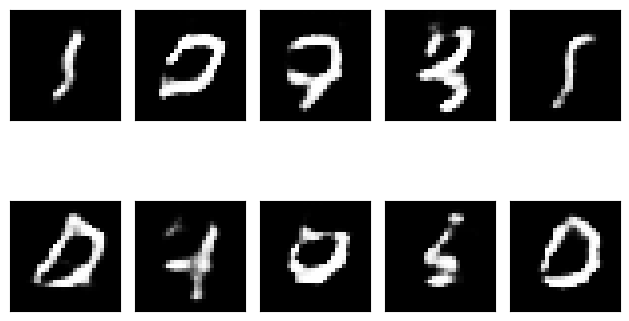

Epoch: 24, disc. loss: 0.657971978187561, gen. loss: 0.7106435894966125. Time for epoch 25 is 15.494208574295044 sec
Epoch: 25, disc. loss: 0.6588735580444336, gen. loss: 0.7028877139091492. Time for epoch 26 is 14.773519039154053 sec
Epoch: 26, disc. loss: 0.667220413684845, gen. loss: 0.6992853879928589. Time for epoch 27 is 14.970288753509521 sec
Epoch: 27, disc. loss: 0.6500879526138306, gen. loss: 0.7592337131500244. Time for epoch 28 is 14.784094095230103 sec
Epoch: 28, disc. loss: 0.5805613994598389, gen. loss: 0.8721464276313782. Time for epoch 29 is 14.86128282546997 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


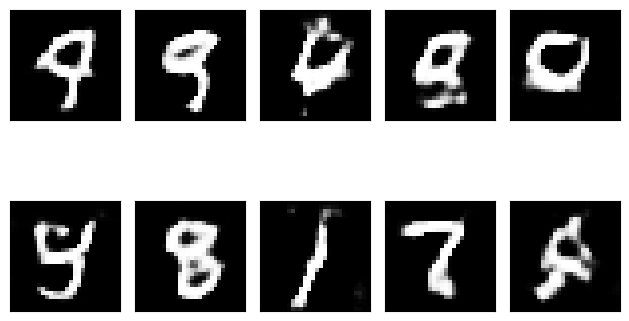

Epoch: 29, disc. loss: 0.6076414585113525, gen. loss: 0.7623645067214966. Time for epoch 30 is 15.104738235473633 sec
Epoch: 30, disc. loss: 0.6562867164611816, gen. loss: 0.9307528734207153. Time for epoch 31 is 14.882676362991333 sec
Epoch: 31, disc. loss: 0.6330920457839966, gen. loss: 0.7486884593963623. Time for epoch 32 is 14.783373355865479 sec
Epoch: 32, disc. loss: 0.6971582174301147, gen. loss: 0.751884937286377. Time for epoch 33 is 14.958292722702026 sec
Epoch: 33, disc. loss: 0.6852498054504395, gen. loss: 0.6570791006088257. Time for epoch 34 is 14.906047105789185 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


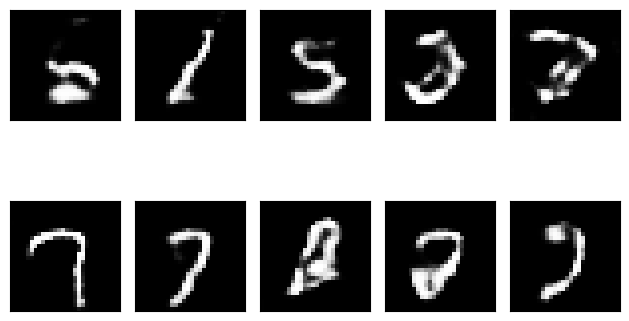

Epoch: 34, disc. loss: 0.6889940500259399, gen. loss: 0.8139479756355286. Time for epoch 35 is 15.168004035949707 sec
Epoch: 35, disc. loss: 0.6744011640548706, gen. loss: 0.767458975315094. Time for epoch 36 is 14.918068170547485 sec
Epoch: 36, disc. loss: 0.6778888702392578, gen. loss: 0.6607442498207092. Time for epoch 37 is 14.8855459690094 sec
Epoch: 37, disc. loss: 0.6185481548309326, gen. loss: 0.7412528991699219. Time for epoch 38 is 14.88838815689087 sec
Epoch: 38, disc. loss: 0.7243434190750122, gen. loss: 0.6419215202331543. Time for epoch 39 is 14.821683645248413 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


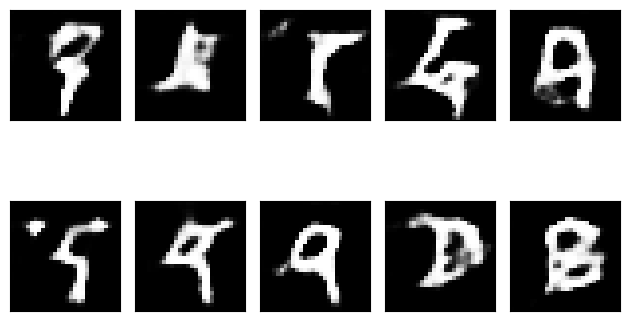

Epoch: 39, disc. loss: 0.602579653263092, gen. loss: 0.7845447659492493. Time for epoch 40 is 15.363247632980347 sec
Epoch: 40, disc. loss: 0.649060845375061, gen. loss: 0.8223447799682617. Time for epoch 41 is 14.940187454223633 sec
Epoch: 41, disc. loss: 0.6783491373062134, gen. loss: 0.7144913077354431. Time for epoch 42 is 14.8873770236969 sec
Epoch: 42, disc. loss: 0.6529629230499268, gen. loss: 0.7388748526573181. Time for epoch 43 is 14.859762907028198 sec
Epoch: 43, disc. loss: 0.7022591233253479, gen. loss: 0.5564385652542114. Time for epoch 44 is 14.911273956298828 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


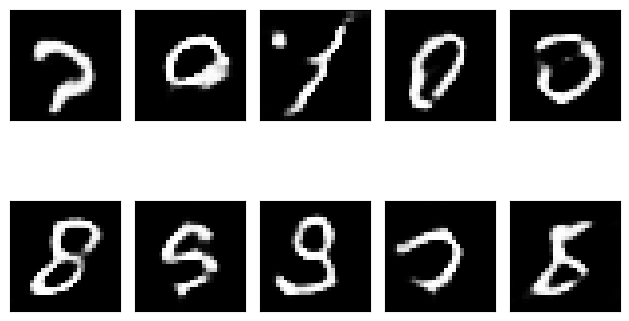

Epoch: 44, disc. loss: 0.6814289093017578, gen. loss: 0.6074221730232239. Time for epoch 45 is 15.25145149230957 sec
Epoch: 45, disc. loss: 0.5644855499267578, gen. loss: 0.7512781620025635. Time for epoch 46 is 14.969728469848633 sec
Epoch: 46, disc. loss: 0.6165301203727722, gen. loss: 0.7925304174423218. Time for epoch 47 is 14.867644309997559 sec
Epoch: 47, disc. loss: 0.6456835865974426, gen. loss: 0.8052970767021179. Time for epoch 48 is 14.93010401725769 sec
Epoch: 48, disc. loss: 0.6863027811050415, gen. loss: 0.7138695120811462. Time for epoch 49 is 15.049960136413574 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


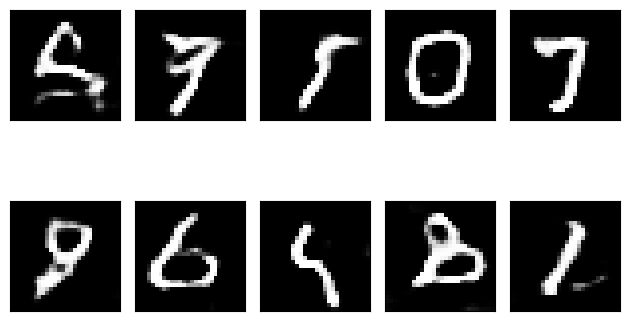

Epoch: 49, disc. loss: 0.6219092607498169, gen. loss: 0.7610151171684265. Time for epoch 50 is 15.941230535507202 sec
Epoch: 50, disc. loss: 0.6844205856323242, gen. loss: 0.6824695467948914. Time for epoch 51 is 15.082793712615967 sec
Epoch: 51, disc. loss: 0.670857310295105, gen. loss: 0.9083759784698486. Time for epoch 52 is 15.112171173095703 sec
Epoch: 52, disc. loss: 0.630394697189331, gen. loss: 0.76816725730896. Time for epoch 53 is 14.930375337600708 sec
Epoch: 53, disc. loss: 0.6831456422805786, gen. loss: 0.611197292804718. Time for epoch 54 is 15.161046266555786 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


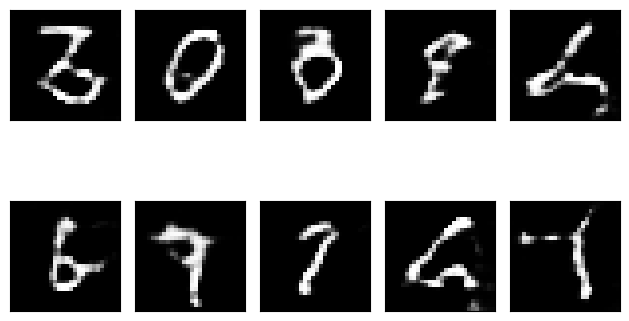

Epoch: 54, disc. loss: 0.6890791654586792, gen. loss: 0.7081451416015625. Time for epoch 55 is 15.453123092651367 sec
Epoch: 55, disc. loss: 0.6763412952423096, gen. loss: 0.8395576477050781. Time for epoch 56 is 14.938061714172363 sec
Epoch: 56, disc. loss: 0.6829628944396973, gen. loss: 0.6736069917678833. Time for epoch 57 is 15.096446990966797 sec
Epoch: 57, disc. loss: 0.6396602392196655, gen. loss: 0.7096958160400391. Time for epoch 58 is 15.137718439102173 sec
Epoch: 58, disc. loss: 0.6482058167457581, gen. loss: 0.8407249450683594. Time for epoch 59 is 15.115657567977905 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


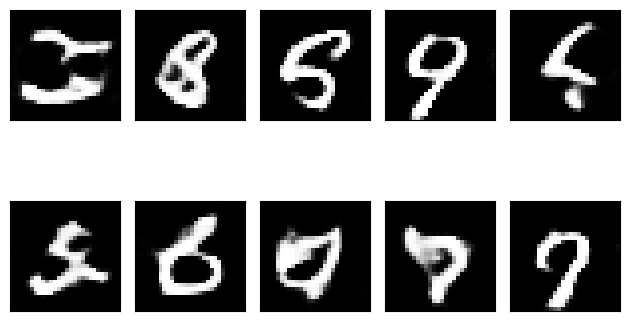

Epoch: 59, disc. loss: 0.6921436786651611, gen. loss: 0.6967411637306213. Time for epoch 60 is 15.223363637924194 sec
Epoch: 60, disc. loss: 0.6034287214279175, gen. loss: 0.8098667860031128. Time for epoch 61 is 14.952807664871216 sec
Epoch: 61, disc. loss: 0.6155911087989807, gen. loss: 0.7758245468139648. Time for epoch 62 is 14.832845449447632 sec
Epoch: 62, disc. loss: 0.6694712042808533, gen. loss: 0.7811222076416016. Time for epoch 63 is 14.901641368865967 sec
Epoch: 63, disc. loss: 0.6389161348342896, gen. loss: 0.7334643602371216. Time for epoch 64 is 14.85806393623352 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


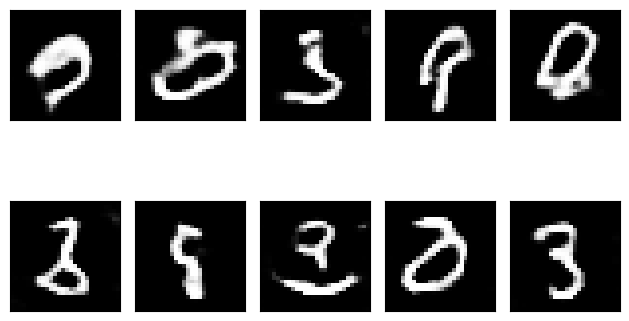

Epoch: 64, disc. loss: 0.6631521582603455, gen. loss: 0.9822728633880615. Time for epoch 65 is 15.280979871749878 sec
Epoch: 65, disc. loss: 0.668590247631073, gen. loss: 0.6806953549385071. Time for epoch 66 is 14.833045244216919 sec
Epoch: 66, disc. loss: 0.6366469860076904, gen. loss: 0.8380017280578613. Time for epoch 67 is 14.881554126739502 sec
Epoch: 67, disc. loss: 0.6419894695281982, gen. loss: 0.7627312541007996. Time for epoch 68 is 14.844897985458374 sec
Epoch: 68, disc. loss: 0.6578729152679443, gen. loss: 0.7851291298866272. Time for epoch 69 is 15.054523706436157 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


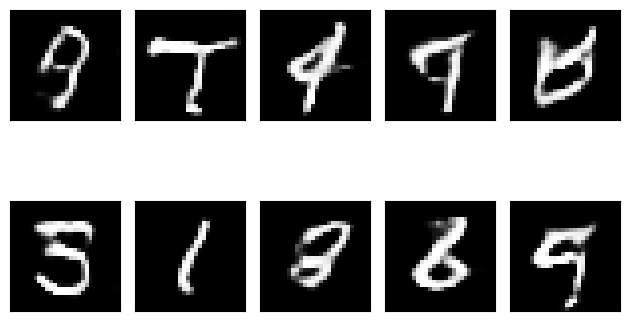

Epoch: 69, disc. loss: 0.650250256061554, gen. loss: 0.7952934503555298. Time for epoch 70 is 15.761980056762695 sec
Epoch: 70, disc. loss: 0.6685432195663452, gen. loss: 0.6853960752487183. Time for epoch 71 is 14.992112159729004 sec
Epoch: 71, disc. loss: 0.5481909513473511, gen. loss: 0.8557301163673401. Time for epoch 72 is 15.000124216079712 sec
Epoch: 72, disc. loss: 0.6516485214233398, gen. loss: 0.8814396262168884. Time for epoch 73 is 15.103199481964111 sec
Epoch: 73, disc. loss: 0.6410355567932129, gen. loss: 0.9813922047615051. Time for epoch 74 is 15.015632152557373 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


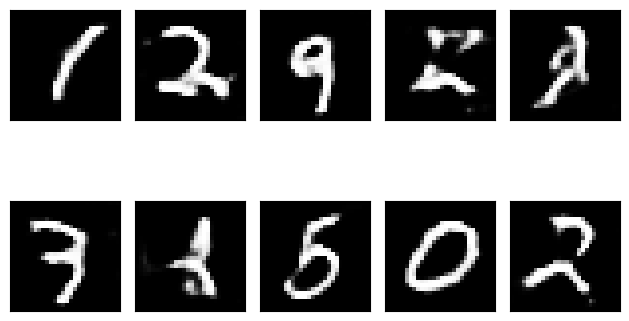

Epoch: 74, disc. loss: 0.6111400127410889, gen. loss: 0.8225597739219666. Time for epoch 75 is 15.497897148132324 sec
Epoch: 75, disc. loss: 0.6413494944572449, gen. loss: 0.8364415764808655. Time for epoch 76 is 15.180635452270508 sec
Epoch: 76, disc. loss: 0.6690425872802734, gen. loss: 0.7179898619651794. Time for epoch 77 is 15.06952691078186 sec
Epoch: 77, disc. loss: 0.6703963875770569, gen. loss: 0.734589159488678. Time for epoch 78 is 14.86806869506836 sec
Epoch: 78, disc. loss: 0.7006160020828247, gen. loss: 0.7361299395561218. Time for epoch 79 is 14.819073915481567 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


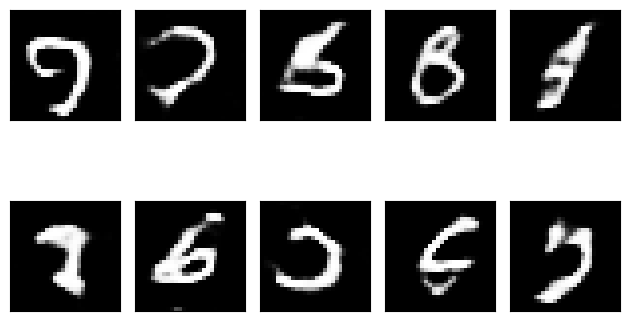

Epoch: 79, disc. loss: 0.6526626348495483, gen. loss: 0.8080626130104065. Time for epoch 80 is 15.353731632232666 sec
Epoch: 80, disc. loss: 0.6818673014640808, gen. loss: 0.7033228874206543. Time for epoch 81 is 14.891162395477295 sec
Epoch: 81, disc. loss: 0.6400567293167114, gen. loss: 0.7462218403816223. Time for epoch 82 is 14.945345878601074 sec
Epoch: 82, disc. loss: 0.6869006752967834, gen. loss: 0.7634178400039673. Time for epoch 83 is 14.849809646606445 sec
Epoch: 83, disc. loss: 0.6288231611251831, gen. loss: 0.8044146299362183. Time for epoch 84 is 14.982100248336792 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


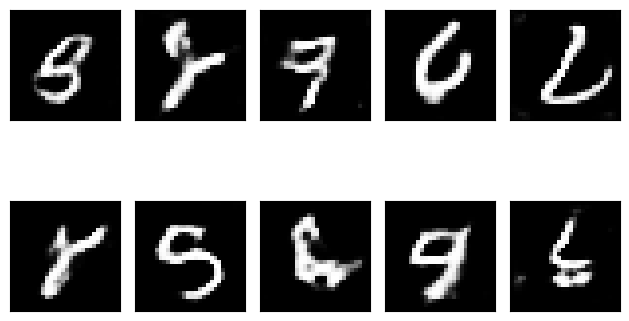

Epoch: 84, disc. loss: 0.5855568647384644, gen. loss: 0.9350789785385132. Time for epoch 85 is 15.23345136642456 sec
Epoch: 85, disc. loss: 0.7044696807861328, gen. loss: 0.8233985900878906. Time for epoch 86 is 14.948464393615723 sec
Epoch: 86, disc. loss: 0.6953310966491699, gen. loss: 0.7288048267364502. Time for epoch 87 is 14.834830045700073 sec
Epoch: 87, disc. loss: 0.7061268091201782, gen. loss: 0.7061236500740051. Time for epoch 88 is 15.101627826690674 sec
Epoch: 88, disc. loss: 0.6359469294548035, gen. loss: 0.743811309337616. Time for epoch 89 is 14.909914016723633 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


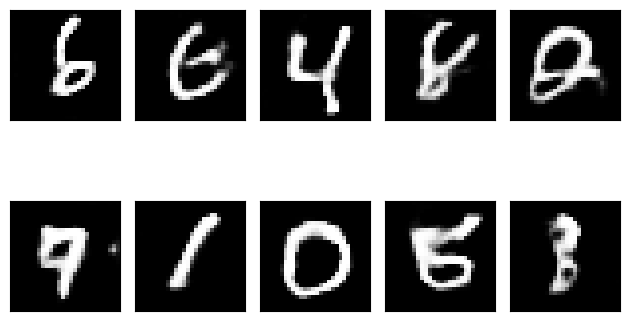

Epoch: 89, disc. loss: 0.6362831592559814, gen. loss: 0.7268696427345276. Time for epoch 90 is 15.325321912765503 sec
Epoch: 90, disc. loss: 0.6635388135910034, gen. loss: 0.7088779807090759. Time for epoch 91 is 14.846603631973267 sec
Epoch: 91, disc. loss: 0.6479616165161133, gen. loss: 0.7775058746337891. Time for epoch 92 is 14.982200384140015 sec
Epoch: 92, disc. loss: 0.7043201923370361, gen. loss: 0.8088491559028625. Time for epoch 93 is 14.95723295211792 sec
Epoch: 93, disc. loss: 0.6644558906555176, gen. loss: 0.8249207735061646. Time for epoch 94 is 14.953861236572266 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


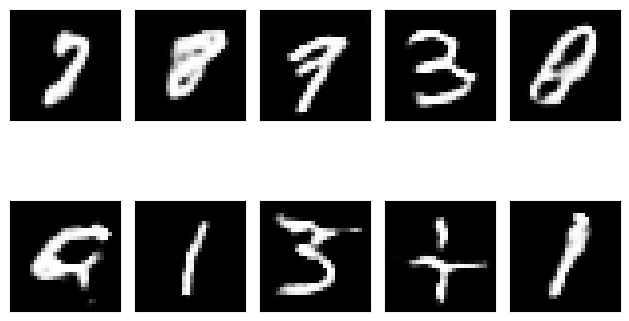

Epoch: 94, disc. loss: 0.6823227405548096, gen. loss: 0.7198392748832703. Time for epoch 95 is 15.20338487625122 sec
Epoch: 95, disc. loss: 0.6470063924789429, gen. loss: 0.7784203290939331. Time for epoch 96 is 15.105327844619751 sec
Epoch: 96, disc. loss: 0.647836446762085, gen. loss: 0.8349534869194031. Time for epoch 97 is 14.828664541244507 sec
Epoch: 97, disc. loss: 0.6453954577445984, gen. loss: 0.7142941951751709. Time for epoch 98 is 14.986755847930908 sec
Epoch: 98, disc. loss: 0.6711744070053101, gen. loss: 0.8528023958206177. Time for epoch 99 is 14.813839197158813 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


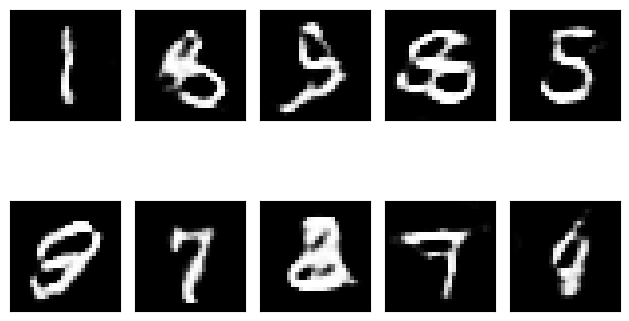

Epoch: 99, disc. loss: 0.6277920007705688, gen. loss: 0.8576013445854187. Time for epoch 100 is 15.23102355003357 sec


In [ ]:
import time

# smooth = 0.1
add_noise_labels = True
noise_labels = 0.02

gen_optimizer = Adam( learning_rate=0.0002, beta_1=0.5 )
disc_optimizer = Adam( learning_rate=0.0002, beta_1=0.5 )
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

@tf.function
def train_step( X_real ):
    z = tf.random.normal( [batch_size, latent_dim] )
    X_fake = generator.predict_on_batch( z )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      X_fake = generator( z, training=True )

      real_output = discriminator( X_real, training=True)
      fake_output = discriminator( X_fake, training=True)

      y_real = tf.ones_like(real_output)
      y_fake = tf.zeros_like(fake_output)
      # Add random noise to the labels
      if add_noise_labels:
          y_real += noise_labels * tf.random.uniform(tf.shape(y_real))
          y_fake += noise_labels * tf.random.uniform(tf.shape(y_fake))

      real_loss = cross_entropy( y_real, real_output)
      fake_loss = cross_entropy( y_fake, fake_output)
      disc_loss = 0.5 * ( real_loss + fake_loss )

      gen_loss = cross_entropy( tf.ones_like(fake_output), fake_output )

    gen_grads  = gen_tape.gradient( gen_loss, generator.trainable_variables )
    disc_grads = disc_tape.gradient( disc_loss, discriminator.trainable_variables )

    gen_optimizer.apply_gradients( zip( gen_grads, generator.trainable_variables) )
    disc_optimizer.apply_gradients( zip( disc_grads, discriminator.trainable_variables) )

    return (disc_loss, gen_loss)

def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for X_batch in dataset:
      dloss, gloss = train_step( X_batch )

    if (epoch + 1) % 5 == 0:
        samples = 10
        X_ = generator.predict( tf.random.normal( [samples, latent_dim] ) )
        for k in range(samples):
            plt.subplot(2, 5, k+1)
            plt.imshow( X_[k].reshape(28, 28), cmap='gray')
            plt.xticks([])
            plt.yticks([])
        plt.tight_layout()
        plt.show()

    print ( "Epoch: {}, disc. loss: {}, gen. loss: {}.".format( epoch, dloss, gloss ),
            "Time for epoch {} is {} sec".format(epoch + 1, time.time()-start) )

epochs = 100
train(train_dataset, epochs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


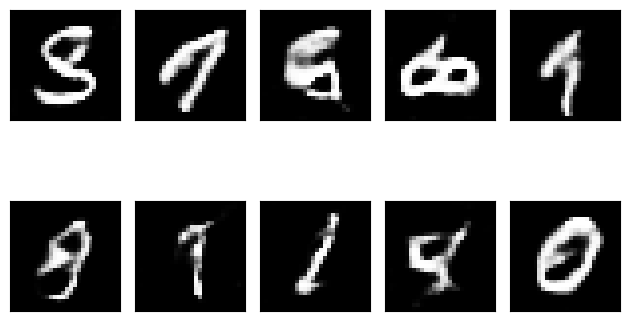

In [ ]:
samples = 10
X_ = generator.predict( tf.random.normal( [samples, latent_dim] ) )
for k in range(samples):
    plt.subplot(2, 5, k+1)
    plt.imshow( X_[k].reshape(28, 28), cmap='gray')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()